230481E
PERERA K.W.A.O.V

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = sorted(breakpoints, key=lambda p: p[0])  # sort by x
    lut = np.zeros(256, dtype=np.float64)  # lookup table

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        xs = np.arange(x0, x1 + 1)
        ys = np.linspace(y0, y1, x1 - x0 + 1)  # linear interpolation
        lut[x0:x1 + 1] = ys

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    transformed = cv2.LUT(im, lut)  # apply mapping
    return transformed, lut

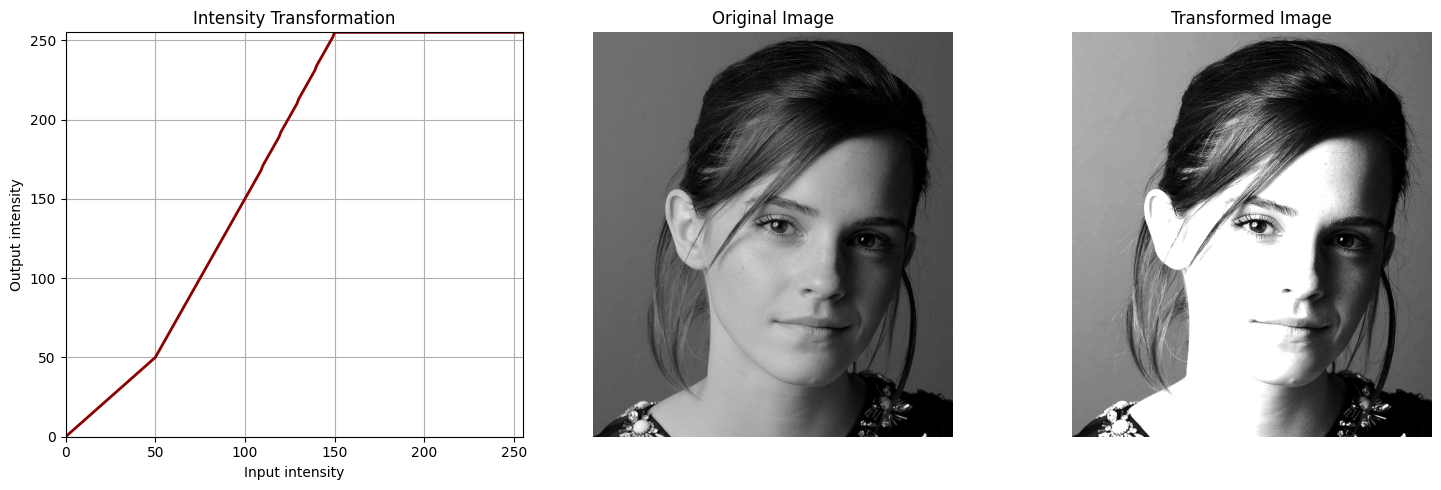

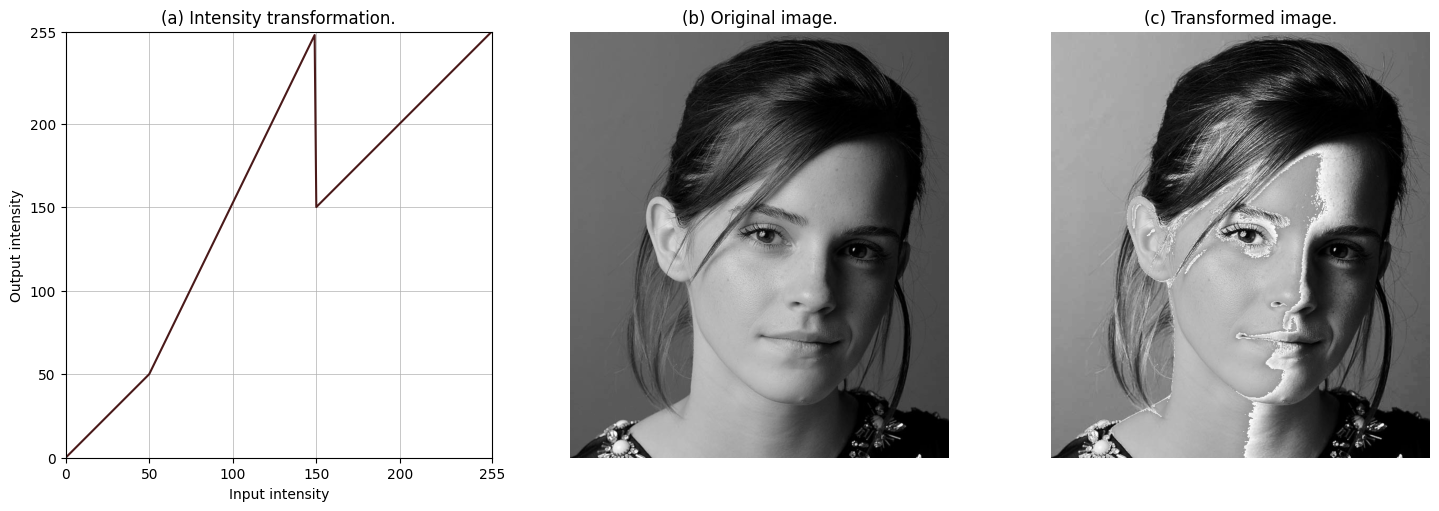

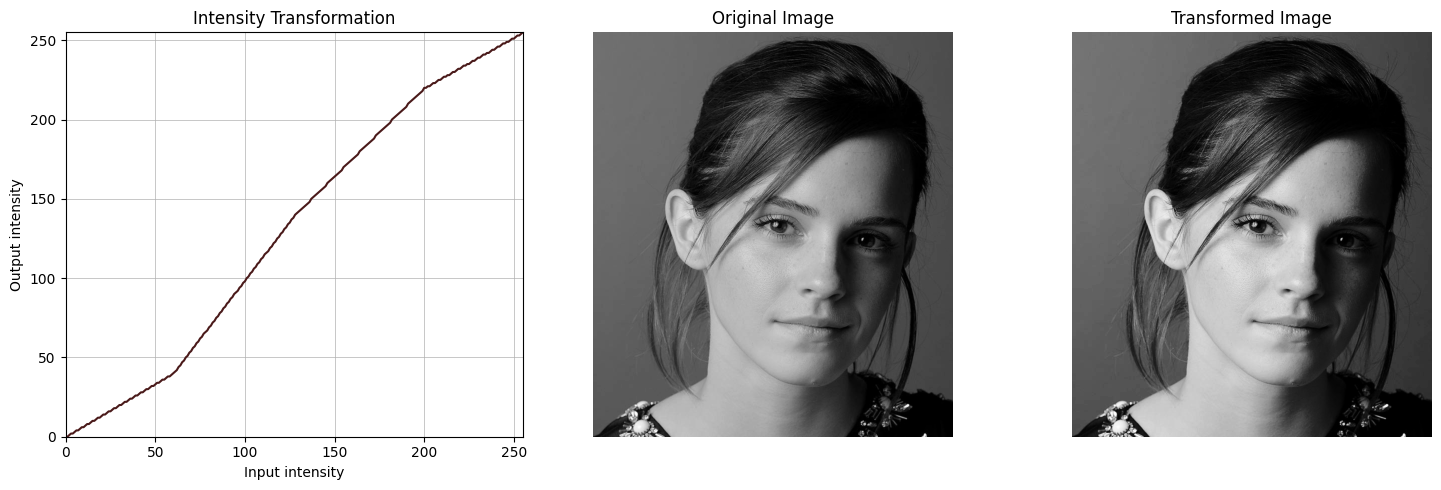

In [33]:
img = cv2.imread('images/images/q1.jpeg', cv2.IMREAD_GRAYSCALE)  # load the image in  grayscale

breakpoints = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]  # transformation

transformed_img, lut = intensity_transform(img, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='darkred', linewidth=2)  # transformation curve
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity Transformation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')  # original
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_img, cmap='gray')  # after transform
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

breakpoints = [
    [0, 0],
    [50, 50],
    [150, 255],
    [150, 150],
    [255, 255]
] 

lut = np.zeros(256, dtype=np.float64)
for i in range(len(breakpoints) - 1):
    x0, y0 = breakpoints[i]
    x1, y1 = breakpoints[i + 1]
    if x1 == x0:
        continue
    xs = np.arange(x0, x1 + 1)
    ys = np.linspace(y0, y1, x1 - x0 + 1)
    lut[x0:x1 + 1] = ys

lut_uint8 = np.clip(lut, 0, 255).astype(np.uint8)
transformed_img = cv2.LUT(img, lut_uint8)  # apply to image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# transformation curve
axes[0].plot(np.arange(256), lut, color='#4a1a1a', linewidth=1.5)
ticks = [0, 50, 100, 150, 200, 255]
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_aspect('equal')
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('(a) Intensity transformation.')
axes[0].grid(True, linewidth=0.5)

# original image
axes[1].imshow(img, cmap='gray')
axes[1].set_title('(b) Original image.')
axes[1].axis('off')

# transformed image
axes[2].imshow(transformed_img, cmap='gray')
axes[2].set_title('(c) Transformed image.')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Experimented Transform
breakpoints = [
    [0, 0],
    [60, 40],
    [128, 140],
    [200, 220],
    [255, 255]
]  # smooth S-curve

transformed_img, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='#4a1a1a', linewidth=1.5)  # transformation curve
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity Transformation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True, linewidth=0.5)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_img, cmap='gray')  # after transform
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()


Question 2


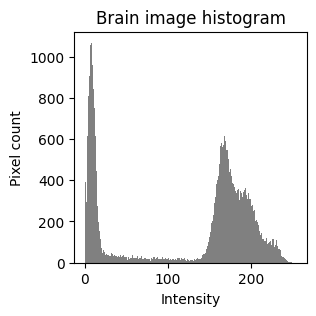

In [5]:
brain_img = cv2.imread('images/images/q2.jpeg', cv2.IMREAD_GRAYSCALE)  # load brain image
plt.figure(figsize=(3, 3))
plt.hist(brain_img.ravel(), bins=256, range=(0, 255), color='gray')  # intensity distribution
plt.xlabel('Intensity')
plt.ylabel('Pixel count')
plt.title('Brain image histogram')
plt.show()

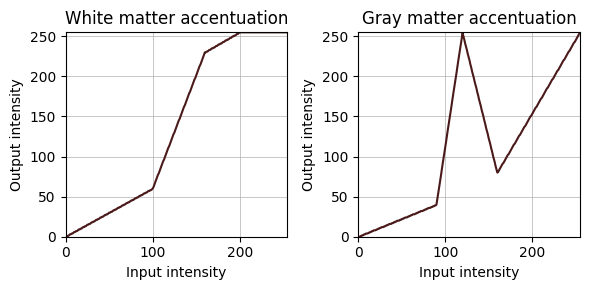

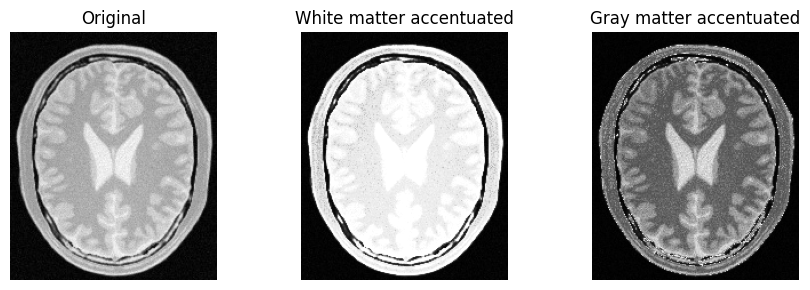

In [12]:
white_matter_bp = [
    [0, 0],
    [100, 60],
    [160, 230],   
    [200, 255],
    [255, 255]
]

white_matter_img, white_lut = intensity_transform(brain_img, white_matter_bp)
gray_matter_bp = [
    [0, 0],
    [90, 40],
    [120, 255],   
    [160, 80],
    [255, 255]
]

gray_matter_img, gray_lut = intensity_transform(brain_img, gray_matter_bp)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].plot(np.arange(256), white_lut, color='#4a1a1a', linewidth=1.5)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter accentuation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True, linewidth=0.5)

axes[1].plot(np.arange(256), gray_lut, color='#4a1a1a', linewidth=1.5)
axes[1].set_xlabel('Input intensity')
axes[1].set_ylabel('Output intensity')
axes[1].set_title('Gray matter accentuation')
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, linewidth=0.5)

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(brain_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(white_matter_img, cmap='gray')
axes[1].set_title('White matter accentuated')
axes[1].axis('off')

axes[2].imshow(gray_matter_img, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Question 3

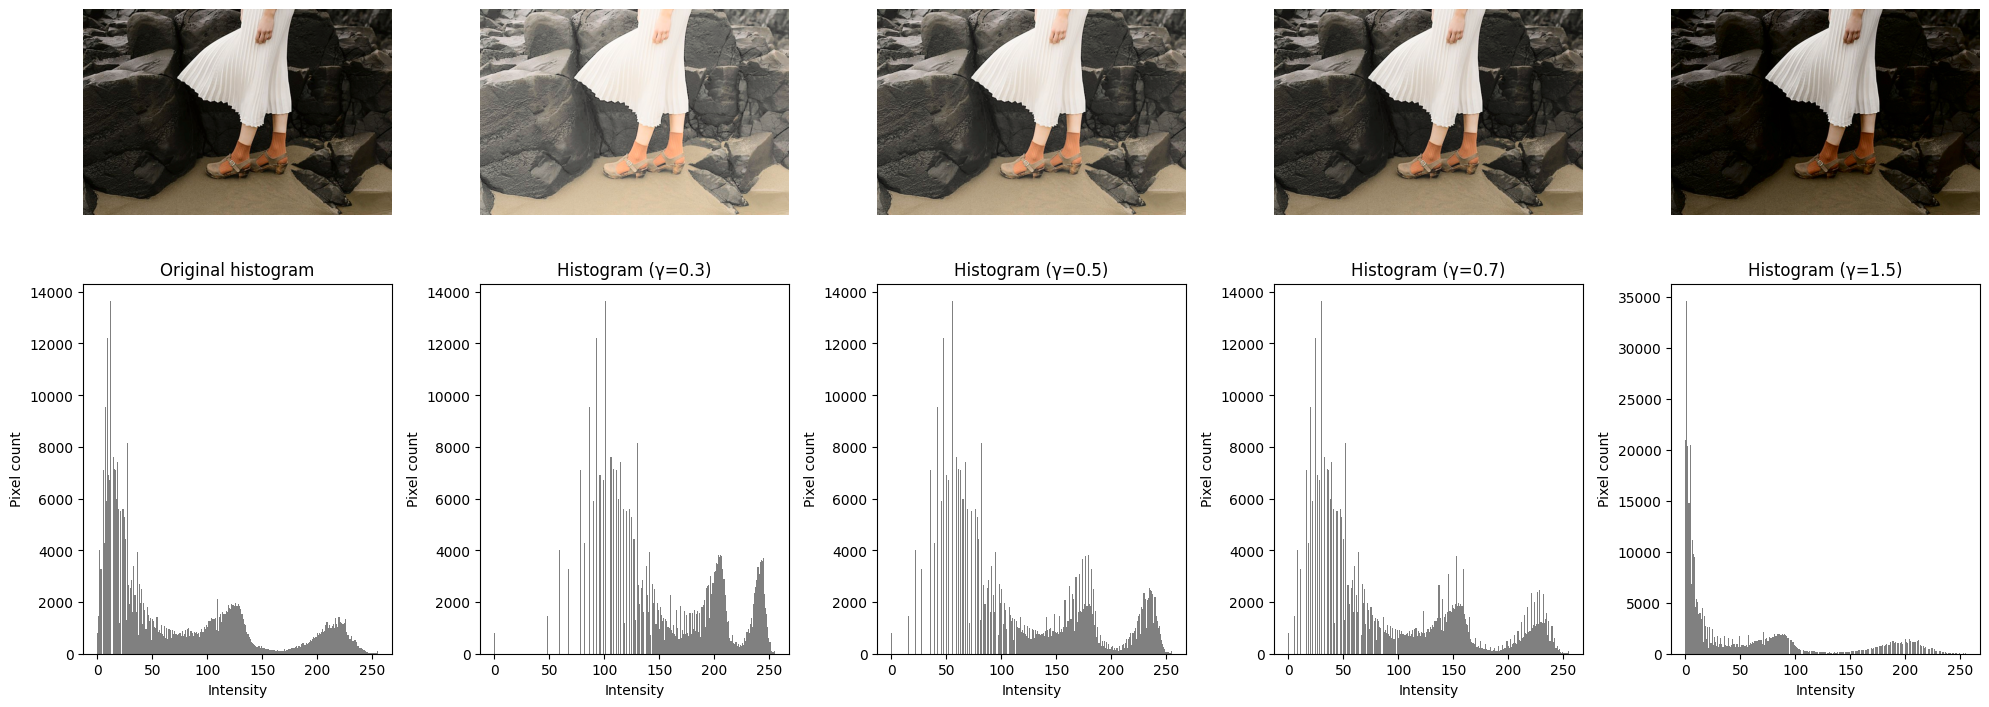

In [37]:
img_gamma = cv2.imread('images/images/image for gamma correction.jpeg')  # BGR by default
img_gamma_rgb = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2RGB)
lab = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2LAB)  # split into L, a, b
L, a, b = cv2.split(lab)

gamma_values = [1, 0.3, 0.5, 0.7, 1.5]  # try several gamma values

def apply_gamma(L, gamma):
    L_norm = L / 255.0  # normalize to [0, 1]
    L_g = np.power(L_norm, gamma)  # apply gamma
    return np.uint8(L_g * 255) 

corrected_images = []  
corrected_L_planes = []  

for gamma in gamma_values:
    L_corrected = apply_gamma(L, gamma)
    lab_corrected = cv2.merge([L_corrected, a, b]) 
    img_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    img_corrected_rgb = cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB)
    corrected_images.append(img_corrected_rgb)
    corrected_L_planes.append(L_corrected)

n = len(gamma_values)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

# top row: images for each gamma
for i, gamma in enumerate(gamma_values):
    axes[0, i].imshow(corrected_images[i])
    title = 'Original' if gamma == 1 else f'γ = {gamma}'
    axes[0, i].axis('off')

# bottom row: histograms for each gamma
for i, gamma in enumerate(gamma_values):
    axes[1, i].hist(corrected_L_planes[i].ravel(), bins=256, range=(0, 255), color='gray')
    title = 'Original histogram' if gamma == 1 else f'Histogram (γ={gamma})'  # same for histogram
    axes[1, i].set_title(title)
    axes[1, i].set_xlabel('Intensity')
    axes[1, i].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()

Question 4

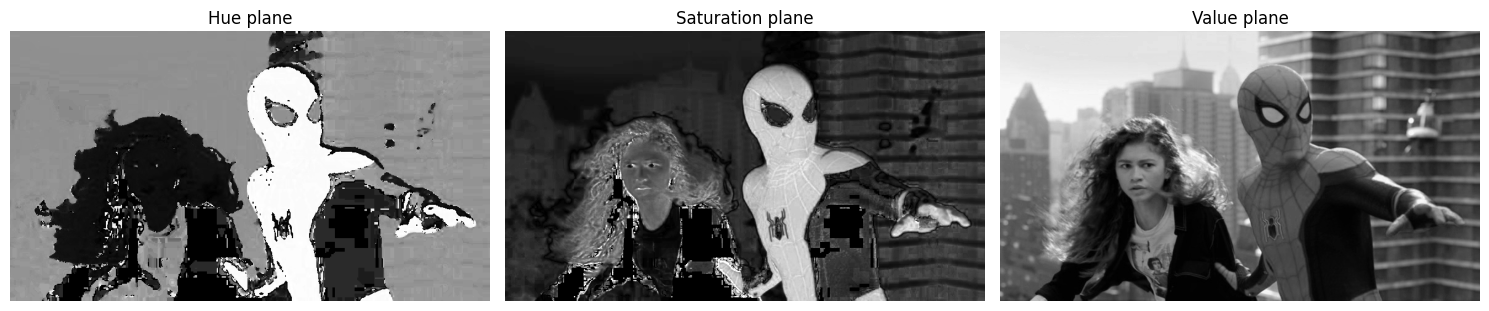

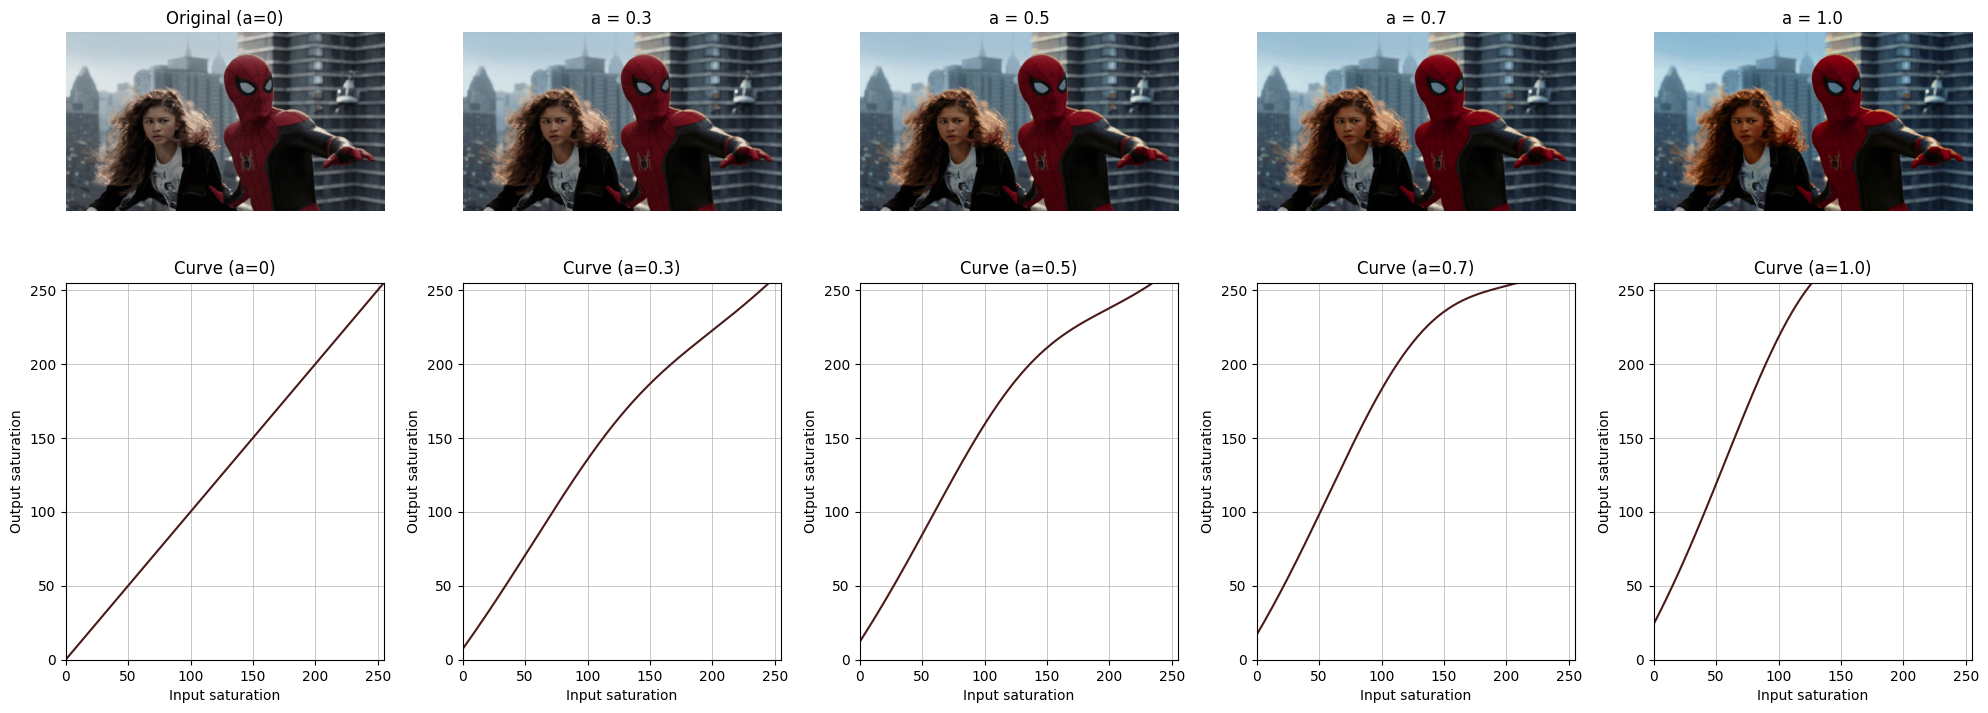

In [39]:
img_vib = cv2.imread('images/images/q4.jpeg')  # BGR 
img_vib_rgb = cv2.cvtColor(img_vib, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img_vib, cv2.COLOR_BGR2HSV)  # convert to HSV
h, s, v = cv2.split(hsv)  # split planes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(h, cmap='gray')
axes[0].set_title('Hue plane')
axes[0].axis('off')
axes[1].imshow(s, cmap='gray')
axes[1].set_title('Saturation plane')
axes[1].axis('off')
axes[2].imshow(v, cmap='gray')
axes[2].set_title('Value plane')
axes[2].axis('off')
plt.tight_layout()
plt.show()

sigma = 70

def vibrance_transform(x, a, sigma):
    x = x.astype(np.float64)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))  # Gaussian boost
    return np.minimum(x + boost, 255)

a_values = [0, 0.3, 0.5, 0.7, 1.0] 

enhanced_images = []  
curves = []  

for a in a_values:
    s_boosted = vibrance_transform(s, a, sigma).astype(np.uint8)  
    hsv_boosted = cv2.merge([h, s_boosted, v])  # recombine planes
    img_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)  
    img_boosted_rgb = cv2.cvtColor(img_boosted, cv2.COLOR_BGR2RGB)
    enhanced_images.append(img_boosted_rgb)

    x_vals = np.arange(0, 256)
    curves.append(vibrance_transform(x_vals, a, sigma))

n = len(a_values)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

# top row: enhanced images
for i, a in enumerate(a_values):
    axes[0, i].imshow(enhanced_images[i])
    title = 'Original (a=0)' if a == 0 else f'a = {a}' 
    axes[0, i].set_title(title)
    axes[0, i].axis('off')

# bottom row: transformation curves
for i, a in enumerate(a_values):
    axes[1, i].plot(np.arange(256), curves[i], color='#4a1a1a', linewidth=1.5)
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_ylim(0, 255)
    axes[1, i].set_xlabel('Input saturation')
    axes[1, i].set_ylabel('Output saturation')
    axes[1, i].set_title(f'Curve (a={a})')
    axes[1, i].grid(True, linewidth=0.5)

plt.tight_layout()
plt.show()

Question 5

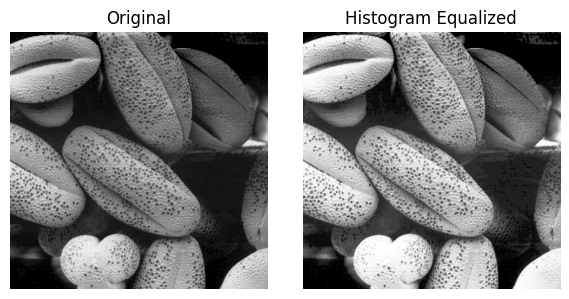

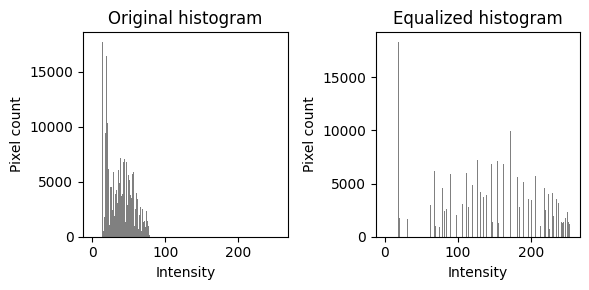

In [43]:
shells_img = cv2.imread('images/images/shells.tif', cv2.IMREAD_GRAYSCALE)  # load as grayscale
def histogram_equalize(im):
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 255))  # pixel count per intensity
    cdf = np.cumsum(hist)  # cumulative sum
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())  # scale to [0, 255]
    lut = cdf_normalized.astype(np.uint8)  # lookup table
    equalized = lut[im]  # map each pixel through the LUT
    return equalized, lut

equalized_img, eq_lut = histogram_equalize(shells_img)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(shells_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(equalized_img, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].hist(shells_img.ravel(), bins=256, range=(0, 255), color='gray')  # before
axes[0].set_title('Original histogram')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Pixel count')

axes[1].hist(equalized_img.ravel(), bins=256, range=(0, 255), color='gray')  # after
axes[1].set_title('Equalized histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()